<a href="https://colab.research.google.com/github/ManLikePamo/Project/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Basic Python Packages
import os
import random
import time
import pickle

# Numpy Library
import numpy as np

# Pandas Library and Settings
import pandas as pd

# Visualization Libraries (Matplotlib, Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

# SKLearn Libarary
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

# Tensorflow Library
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras import callbacks
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.utils import plot_model, to_categorical
from tensorflow.keras.metrics import Accuracy, CategoricalAccuracy
from tensorflow.keras.models import load_model

# OpenCV
import cv2

%matplotlib inline

In [ ]:
gpus = tf.config.experimental.list_physical_devices("GPU")

for gpu in gpus:
    print(gpu)

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
gpus = tf.config.experimental.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
data_directory = "/content/drive/MyDrive/Project/Dataset/project"

print(f"{os.listdir(data_directory)}")

['train', 'test']


In [ ]:
train_directory = os.path.join(data_directory, "train")
test_directory = os.path.join(data_directory, "test")

print(f"Data directory     {data_directory}")
print(f"Train directory    {train_directory}")
print(f"Test directory     {test_directory}")

Data directory     /content/drive/MyDrive/Project/Dataset/project
Train directory    /content/drive/MyDrive/Project/Dataset/project/train
Test directory     /content/drive/MyDrive/Project/Dataset/project/test


In [ ]:
print(f"{os.listdir(train_directory)}")
print(f"{os.listdir(test_directory)}")

['surprise', 'sad', 'fear', 'neutral', 'angry', 'disgust', 'happy']
['surprise', 'sad', 'neutral', 'angry', 'happy', 'disgust', 'fear']


In [ ]:
expressions_list = os.listdir(train_directory)

In [ ]:
train_dataset_info_df = pd.DataFrame(columns=["Expression", "Size", "Proportion %"])
train_expression_size = []

for expression in expressions_list:

    index = expressions_list.index(expression)

    train_expression_directory = os.path.join(train_directory, expression)
    train_expression_size.append(len(os.listdir(train_expression_directory)))

train_expression_proportion = [round((expression_size / sum(train_expression_size)) * 100, 2)\
                               for expression_size in train_expression_size]

train_dataset_info_df["Expression"] = expressions_list
train_dataset_info_df["Size"] = train_expression_size
train_dataset_info_df["Proportion %"] = train_expression_proportion

total_size = train_dataset_info_df["Size"].sum()
total_proportion = train_dataset_info_df["Proportion %"].sum()

total_row = pd.DataFrame({"Expression": ["Total"],
                          "Size": [total_size],
                          "Proportion %": [total_proportion]})

train_dataset_info_df = pd.concat([train_dataset_info_df, total_row], ignore_index=True)

train_dataset_info_df = train_dataset_info_df.style
train_dataset_info_df = train_dataset_info_df.apply(lambda x: ['background-color: green' if\
                                                    i == len(x)-1 else ''\
                                                    for i in range(len(x))], axis=0)

train_dataset_info_df

,Expression,Size,Proportion %
0,surprise,3171,11.050000
1,sad,4830,16.820000
2,fear,4097,14.270000
3,neutral,4965,17.290000
4,angry,3995,13.920000
5,disgust,436,1.520000
6,happy,7215,25.130000
7,Total,28709,100.000000


In [ ]:
test_dataset_info_df = pd.DataFrame(columns=["Expression", "Size", "Proportion %"])
test_expression_size = []

for expression in expressions_list:

    index = expressions_list.index(expression)

    test_expression_directory = os.path.join(test_directory, expression)
    test_expression_size.append(len(os.listdir(test_expression_directory)))

test_expression_proportion = [round((expression_size / sum(test_expression_size)) * 100, 2)\
                              for expression_size in test_expression_size]

test_dataset_info_df["Expression"] = expressions_list
test_dataset_info_df["Size"] = test_expression_size
test_dataset_info_df["Proportion %"] = test_expression_proportion

total_size = test_dataset_info_df["Size"].sum()
total_proportion = test_dataset_info_df["Proportion %"].sum()

total_row = pd.DataFrame({"Expression": ["Total"],
                          "Size": [total_size],
                          "Proportion %": [total_proportion]})

test_dataset_info_df = pd.concat([test_dataset_info_df, total_row], ignore_index=True)

test_dataset_info_df = test_dataset_info_df.style
test_dataset_info_df = test_dataset_info_df.apply(lambda x: ['background-color: green'\
                                                  if i == len(x)-1 else ''\
                                                  for i in range(len(x))], axis=0)

test_dataset_info_df

,Expression,Size,Proportion %
0,surprise,831,11.580000
1,sad,1247,17.370000
2,fear,1024,14.270000
3,neutral,1233,17.180000
4,angry,958,13.350000
5,disgust,111,1.550000
6,happy,1774,24.710000
7,Total,7178,100.010000


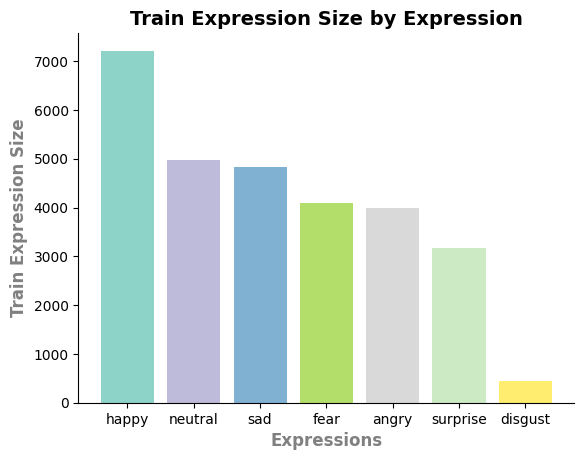

In [ ]:
title_font = {"family" : "arial", "color" : "k", "weight" : "bold", "size" : 14}
axes_font = {"family" : "arial", "color" : "grey", "weight" : "bold", "size" : 12}

sorted_index = np.argsort(train_expression_size)[::-1]

values = np.array(train_expression_size)[sorted_index]
label = np.array(expressions_list)[sorted_index]

colors = plt.cm.Set3(np.linspace(0, 1, len(values)))

plt.bar(label, values, color=colors)

plt.xlabel("Expressions", fontdict=axes_font)
plt.ylabel("Train Expression Size", fontdict=axes_font)
plt.title("Train Expression Size by Expression", fontdict=title_font)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

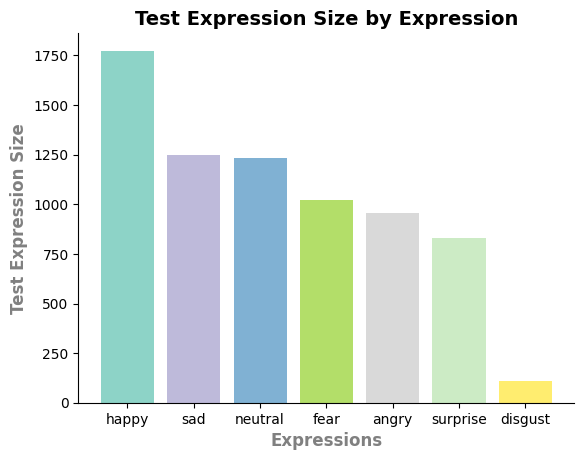

In [ ]:
title_font = {"family" : "arial", "color" : "k", "weight" : "bold", "size" : 14}
axes_font = {"family" : "arial", "color" : "grey", "weight" : "bold", "size" : 12}

sorted_index = np.argsort(test_expression_size)[::-1]

values = np.array(test_expression_size)[sorted_index]
label = np.array(expressions_list)[sorted_index]

colors = plt.cm.Set3(np.linspace(0, 1, len(values)))

plt.bar(label, values, color=colors)

plt.xlabel("Expressions", fontdict=axes_font)
plt.ylabel("Test Expression Size", fontdict=axes_font)
plt.title("Test Expression Size by Expression", fontdict=title_font)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

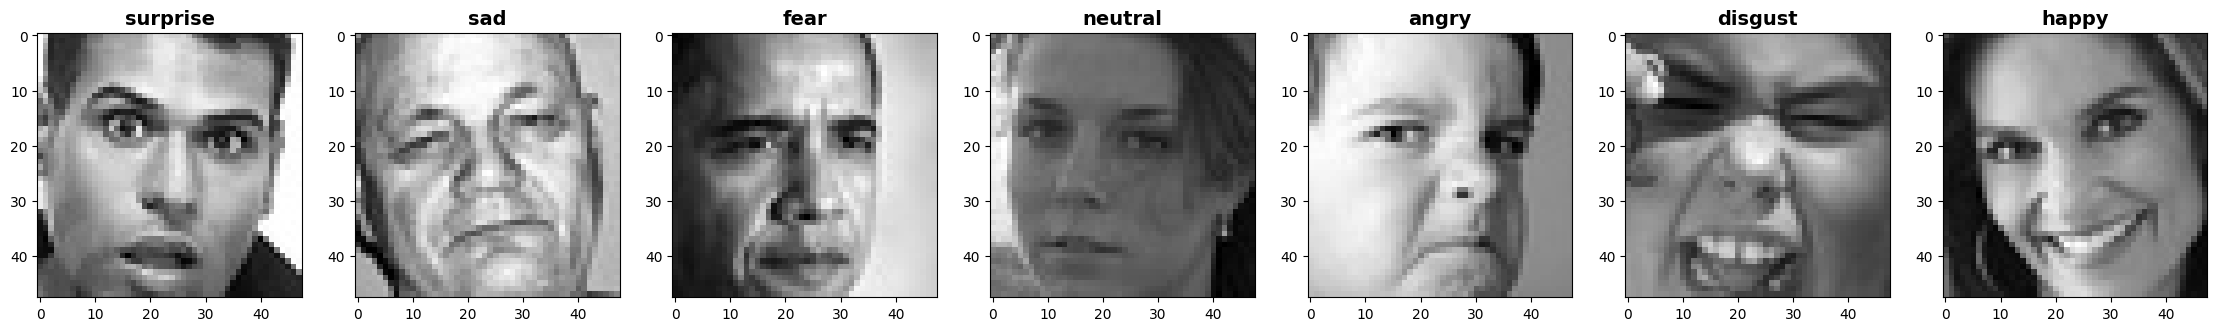

In [ ]:
title_font = {"family" : "arial", "color" : "k", "weight" : "bold", "size" : 14}

fig, axes = plt.subplots(1, len(expressions_list), figsize=(len(expressions_list) * 4, 4))

i = 0

while i < len(expressions_list):

    expression = expressions_list[i]

    expression_directory = os.path.join(train_directory, expression)
    images_list = os.listdir(expression_directory)

    image_directory = os.path.join(expression_directory, random.choice(images_list))

    image = cv2.imread(image_directory, cv2.IMREAD_GRAYSCALE)

    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(expression, fontdict=title_font)

    i += 1

plt.show()

In [ ]:
print(f"Images shape is: {image.shape}")

Images shape is: (48, 48)


In [ ]:
formats = []

for dir in [train_directory, test_directory]:

    i = 0

    print(f"Checking {dir.split('/')[1]} data:")

    while i < len(expressions_list):

        expression = expressions_list[i]

        expression_directory = os.path.join(dir, expression)
        images_list = os.listdir(expression_directory)

        for image in images_list:

            format = image.split(".")[1]

            if format not in formats:
                formats.append(format)

        print(f"    {expression} Checked.")

        i += 1

print("-"*30)
print(f"File formats are: {formats}")

Checking content data:
    surprise Checked.
    sad Checked.
    fear Checked.
    neutral Checked.
    angry Checked.
    disgust Checked.
    happy Checked.
Checking content data:
    surprise Checked.
    sad Checked.
    fear Checked.
    neutral Checked.
    angry Checked.
    disgust Checked.
    happy Checked.
------------------------------
File formats are: ['jpg']


In [ ]:
data = tf.keras.preprocessing.image_dataset_from_directory(train_directory,
                                                           image_size=(48, 48),
                                                           batch_size=64,
                                                           color_mode="grayscale")

print(f"Data type is:       {type(data)}")

Found 28709 files belonging to 7 classes.
Data type is:       <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [ ]:
expressions_list = data.class_names

expressions_list

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [ ]:
data_iterator = data.as_numpy_iterator()

data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x78d9dbd34b30>)

In [ ]:
batch = data_iterator.next()

print(f"Each batch has {len(batch)} parts of data.")
print(f"Each batch's images part has the shape of {batch[0].shape}")
print(f"Each batch's images part has the shape of {batch[1].shape}")

Each batch has 2 parts of data.
Each batch's images part has the shape of (64, 48, 48, 1)
Each batch's images part has the shape of (64,)


Facial expressions are:
    0. angry
    1. disgust
    2. fear
    3. happy
    4. neutral
    5. sad
    6. surprise


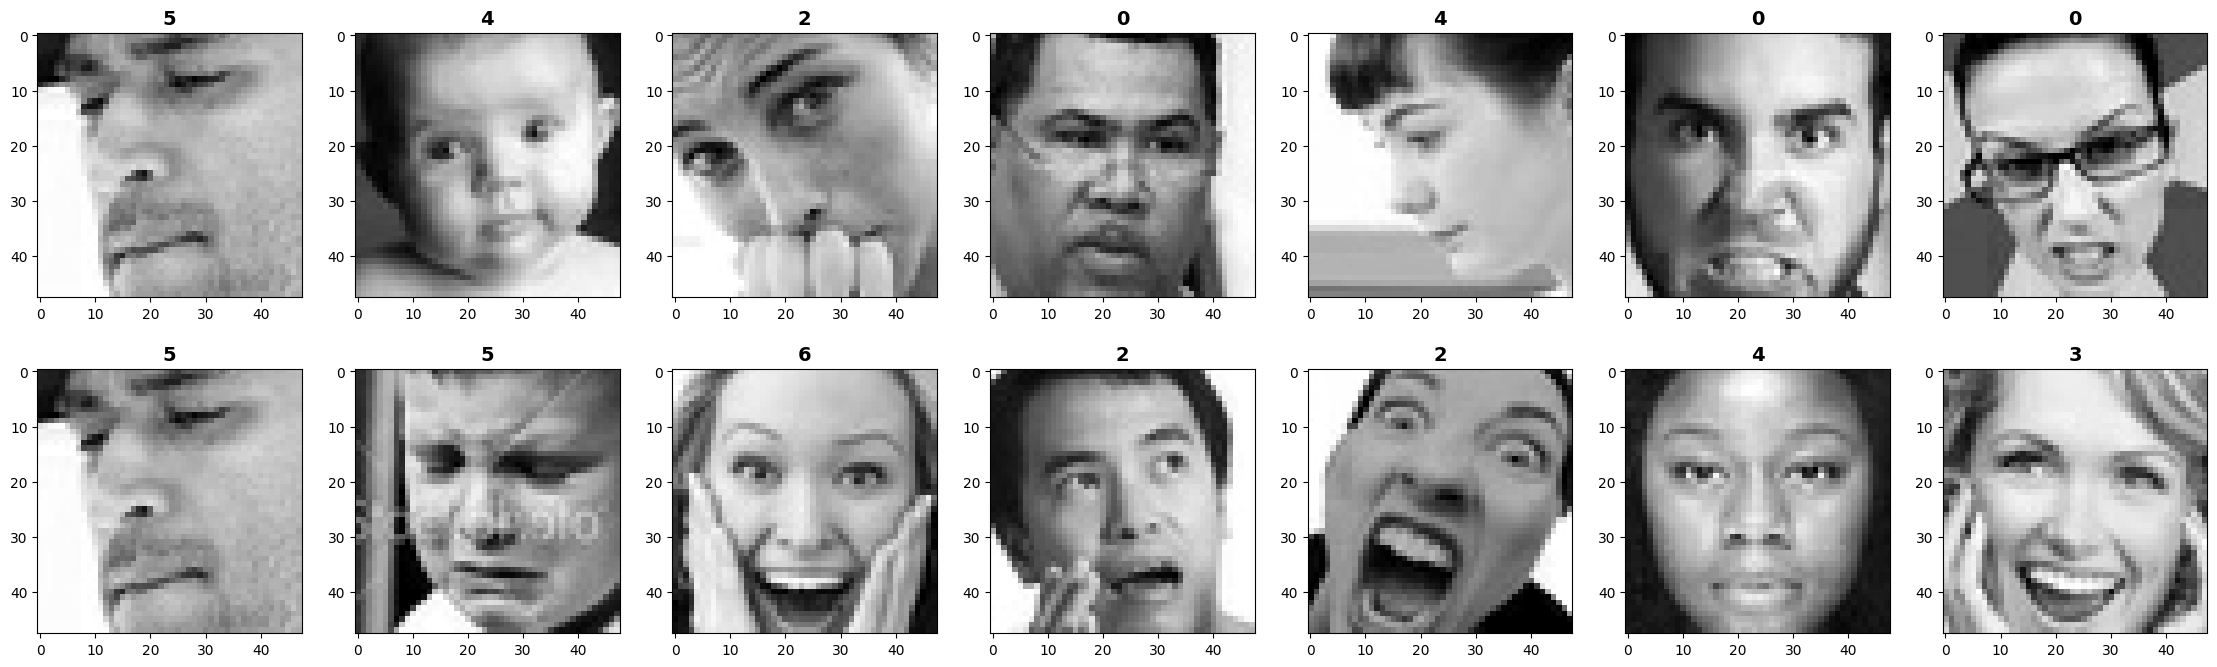

In [ ]:
title_font = {"family" : "arial", "color" : "k", "weight" : "bold", "size" : 14}

print("Facial expressions are:")

for expression in expressions_list:
    print(f"    {expressions_list.index(expression)}. {expression}")

indexes = np.random.randint(0, batch[0].shape[0], 14)

fig, axes = plt.subplots(2, 7, figsize=(28, 8))

i = 0
j = 0

for index in indexes:

    axes[i, j].imshow(batch[0][index].astype(int), cmap="gray")
    axes[i, j].set_title(batch[1][index], fontdict=title_font)

    j += 1

    if j==7:
        i = 1
        j = 0

plt.show()

In [ ]:
print(f"Data Minimum: {batch[0].min()}")
print(f"Data Maximum: {batch[0].max()}")

Data Minimum: 0.0
Data Maximum: 255.0


In [ ]:
data = data.map(lambda x, y: (x/255., y))

In [ ]:
batch = data.as_numpy_iterator().next()

print(f"Data Minimum: {batch[0].min()}")
print(f"Data Maximum: {batch[0].max()}")

Data Minimum: 0.0
Data Maximum: 1.0


In [ ]:
train_size = int(len(data)*0.875)
validation_size = int(len(data)*0.125)

print(f"The train dataset size will be {train_size}.")
print(f"The validation dataset size will be {validation_size}.")

The train dataset size will be 392.
The validation dataset size will be 56.


In [ ]:
train = data.take(train_size)
validation = data.skip(train_size).take(validation_size)

In [ ]:
def get_compiled_model(input_shape, optimizer, loss, metrics):
    """
    This is a Python function that compiles and returns a neural network model using the Keras library.

    Args:
        input_shape (tuple)             The shape of the input data for the model.
        optimizer (str or callable)     The optimizer to use for training the model.
        loss (str or callable)          The loss function to use during training.
        metrics (list)                  The list of evaluation metrics for the model.

    Returns:
        model ()                        The compiled Keras model object that can be used for training.
    """

    model = Sequential()

    # Convolutional and pooling layers

    model.add(Conv2D(32, (3, 3), strides=1, activation="relu",
                     padding="same", input_shape=(48, 48, 1)))

    model.add(Conv2D(64, (3, 3), strides=1, activation="relu",
                     padding="same"))

    model.add(BatchNormalization())

    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Dropout(0.25))

    # Convolutional and pooling layers

    model.add(Conv2D(128, (3, 3), strides=1, activation="relu",
                     padding="same", kernel_regularizer=tf.keras.regularizers.l2(0.01)))

    model.add(Conv2D(256, (3, 3), strides=1, activation="relu",
                     padding="same", kernel_regularizer=tf.keras.regularizers.l2(0.01)))

    model.add(BatchNormalization())

    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Dropout(0.25))

    # Flatten and dense layer

    model.add(Flatten())

    model.add(Dense(256, activation="relu"))

    model.add(BatchNormalization())

    model.add(Dropout(0.25))

    # Flatten and dense layer

    model.add(Dense(512, activation="relu"))

    model.add(BatchNormalization())

    model.add(Dropout(0.25))

    # Final layer

    model.add(Dense(7, activation="softmax"))

    # Compiler

    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    return model

In [ ]:
def train_model(model, train_data, epochs, validation_data, callbacks):
    """
    Summary:
    This is a Python function that trains a given neural network model
    on the provided training data and returns the training history.

    Args:
        model (tensorflow.keras model)          The neural network model object to train.
        train_data (numpy.ndarray)              The training data to use for training the model.
        train_target (numpy.ndarray)            The target values for the training data.
        epochs (int)                            The number of epochs to train the model.
        validation_data (numpy.ndarray)         The validation data to use for evaluation.
        callbacks (list)                        A list of Keras callbacks to use during training.

    Returns:
        history ()                              The training history object that contains information
                                                about the training and validation metrics over each epoch.
    """

    history = model.fit(train_data,
                        epochs=epochs,
                        validation_data=validation_data,
                        callbacks=callbacks,
                        verbose=1)

    return history

In [ ]:
class TrainingCallbacks(Callback):

    def __init__(self):
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print("Starting training ...")

    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        print(f"Epoch {epoch + 1} completed in {elapsed_time:.2f} seconds")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.start_time
        print(f"Training finished in {total_time:.2f} seconds")

logs_cb = callbacks.TensorBoard(log_dir="logs")

checkpoint = callbacks.ModelCheckpoint(filepath=os.path.join("checkpoints", "model.h5"),
                                       save_best_only=True,
                                       monitor="val_accuracy")

callbacks_list = [TrainingCallbacks(), logs_cb, checkpoint]

In [ ]:
model = get_compiled_model((48, 48, 1),
                           optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                           loss="sparse_categorical_crossentropy",
                           metrics=["accuracy"])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,964,807 (38.01 MB)

 Trainable params: 9,962,631 (38.00 MB)

 Non-trainable params: 2,176 (8.50 KB)

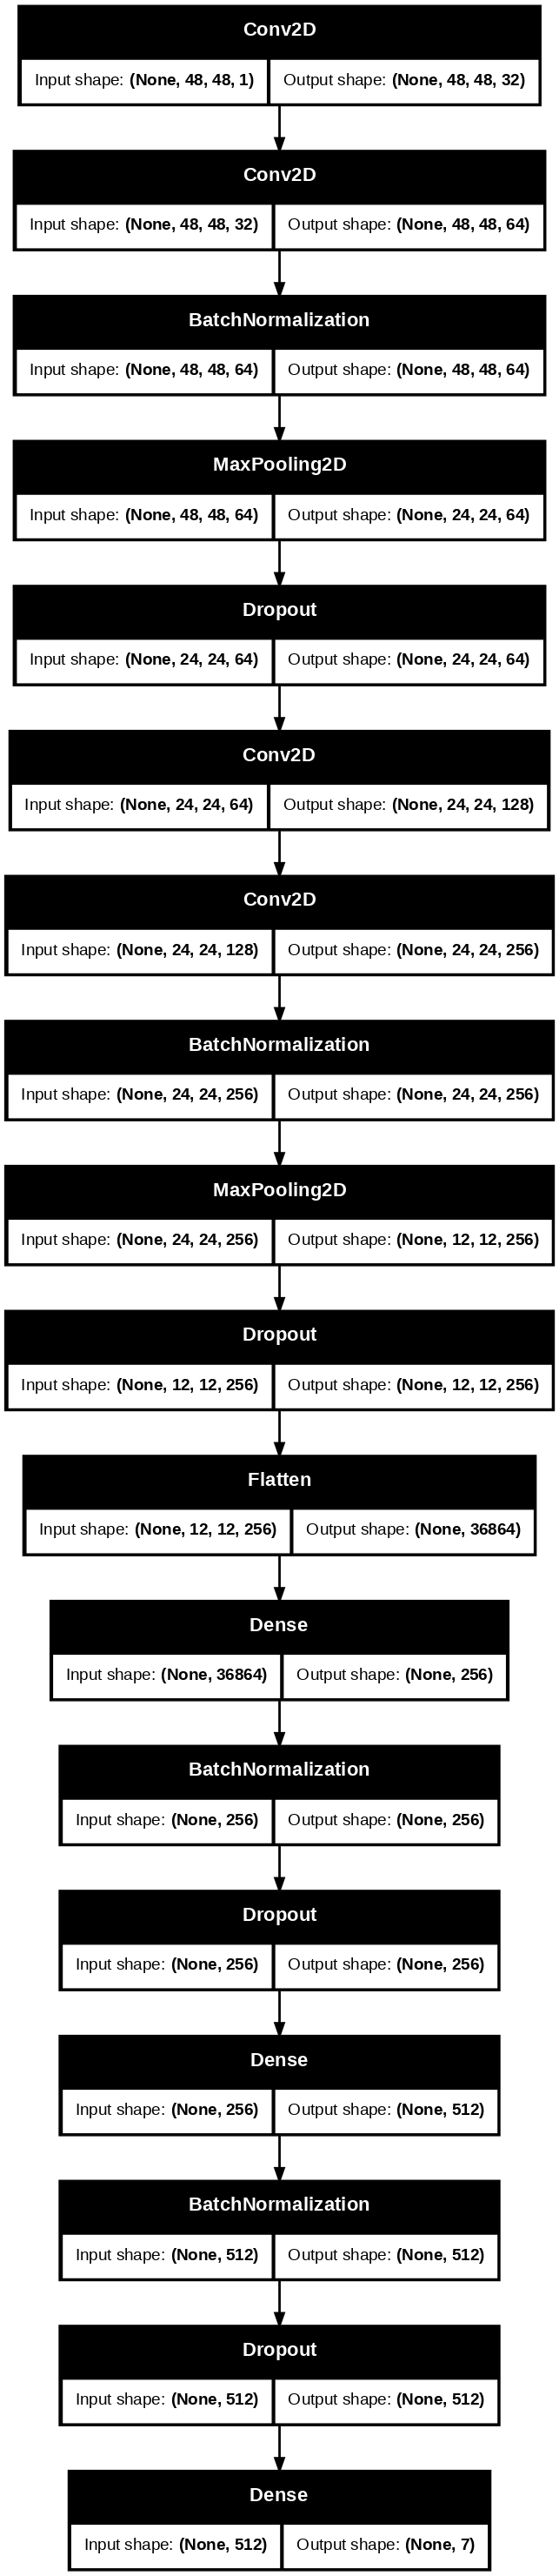

In [ ]:
plot_model(model, show_shapes=True,
           show_layer_names=False,
           expand_nested=True,
           rankdir="TB",
           dpi=100)

In [ ]:
history = train_model(model,
                      train_data=train,
                      epochs=60,
                      validation_data=validation,
                      callbacks=callbacks_list)

Starting training ...
Epoch 1/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2345 - loss: 4.8233

Epoch 1 completed in 631.22 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 631s 2s/step - accuracy: 0.2759 - loss: 4.5519 - val_accuracy: 0.2514 - val_loss: 7.1003
Epoch 2/60
390/392 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3597 - loss: 3.9804

Epoch 2 completed in 691.70 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 61s 155ms/step - accuracy: 0.3691 - loss: 3.8611 - val_accuracy: 0.3993 - val_loss: 3.5904
Epoch 3/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4225 - loss: 3.4534

Epoch 3 completed in 751.60 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.4285 - loss: 3.3554 - val_accuracy: 0.4481 - val_loss: 3.1328
Epoch 4/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4580 - loss: 3.0491

Epoch 4 completed in 812.07 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 154ms/step - accuracy: 0.4658 - loss: 2.9609 - val_accuracy: 0.4593 - val_loss: 2.8229
Epoch 5/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5016 - loss: 2.6860

...

Epoch 24 completed in 2010.43 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.9422 - loss: 0.4040 - val_accuracy: 0.6124 - val_loss: 1.8558
Epoch 25/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9460 - loss: 0.3782Epoch 25 completed in 2070.79 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.9428 - loss: 0.3817 - val_accuracy: 0.6021 - val_loss: 1.8330
Epoch 26/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9462 - loss: 0.3672

Epoch 26 completed in 2130.64 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 154ms/step - accuracy: 0.9478 - loss: 0.3612 - val_accuracy: 0.6208 - val_loss: 1.8553
Epoch 27/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9502 - loss: 0.3492

Epoch 27 completed in 2190.56 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.9496 - loss: 0.3506 - val_accuracy: 0.6247 - val_loss: 1.8983
Epoch 28/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9518 - loss: 0.3293Epoch 28 completed in 2250.55 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.9518 - loss: 0.3323 - val_accuracy: 0.6127 - val_loss: 1.8767
Epoch 29/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9522 - loss: 0.3248Epoch 29 completed in 2310.85 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 154ms/step - accuracy: 0.9495 - loss: 0.3297 - val_accuracy: 0.6055 - val_loss: 1.9078
Epoch 30/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9520 - loss: 0.3151Epoch 30 completed in 2370.17 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 59s 151ms/step - accuracy: 0.9515 - loss: 0.3159 - val_accuracy: 0.6169 - val_loss: 1.8696
Epoch 31/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9540 - loss: 0.3060Epoch 31 completed i

Epoch 37 completed in 2787.14 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 59s 152ms/step - accuracy: 0.9638 - loss: 0.2462 - val_accuracy: 0.6278 - val_loss: 1.8813
Epoch 38/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9671 - loss: 0.2338Epoch 38 completed in 2847.30 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.9647 - loss: 0.2403 - val_accuracy: 0.6250 - val_loss: 1.9413
Epoch 39/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9669 - loss: 0.2258Epoch 39 completed in 2906.77 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 59s 152ms/step - accuracy: 0.9656 - loss: 0.2303 - val_accuracy: 0.6233 - val_loss: 1.9573
Epoch 40/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9694 - loss: 0.2177Epoch 40 completed in 2966.64 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.9672 - loss: 0.2223 - val_accuracy: 0.6203 - val_loss: 1.8718
Epoch 41/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9663 - loss: 0.2222Epoch 41 completed i

Epoch 54 completed in 3798.45 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.9743 - loss: 0.1717 - val_accuracy: 0.6359 - val_loss: 2.1032
Epoch 55/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9741 - loss: 0.1733Epoch 55 completed in 3858.84 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.9736 - loss: 0.1737 - val_accuracy: 0.6275 - val_loss: 1.9921
Epoch 56/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9774 - loss: 0.1620Epoch 56 completed in 3918.85 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.9754 - loss: 0.1668 - val_accuracy: 0.6211 - val_loss: 1.9664
Epoch 57/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9772 - loss: 0.1632Epoch 57 completed in 3978.60 seconds
392/392 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.9761 - loss: 0.1650 - val_accuracy: 0.6250 - val_loss: 1.9935
Epoch 58/60
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9770 - loss: 0.1570Epoch 58 completed i

In [ ]:
# The model's history can be saved using this block of code.

"""with open(os.path.join("history", "history.pkl"), "wb") as f:
    pickle.dump(history.history, f)"""

'with open(os.path.join("history", "history.pkl"), "wb") as f:\n    pickle.dump(history.history, f)'

In [ ]:
# The model can be loaded and the model's history can be read using this block of code.


"""model = load_model(os.path.join("/content/drive/MyDrive/Project/Dataset/model", "model.h5"))

with open(os.path.join("history", "history.pkl"), "rb") as f:
    history = pickle.load(f)"""

# Ensure history is the dictionary of logs, preventing AttributeError on re-execution
if not isinstance(history, dict):
    history = history.history

In [ ]:
history_df = pd.DataFrame(history)

history_df

,accuracy,loss,val_accuracy,val_loss
0,0.275949,4.551902,0.251395,7.100263
1,0.369061,3.861122,0.399275,3.590358
2,0.428452,3.355377,0.448103,3.132846
3,0.465800,2.960936,0.459263,2.822878
4,0.507215,2.615091,0.491071,2.555517
5,0.544005,2.334394,0.531250,2.314834
6,0.577049,2.091673,0.545480,2.128752
7,0.619858,1.863645,0.567801,1.997295
8,0.650231,1.672831,0.565011,1.929171
9,0.685746,1.500869,0.592634,1.801264


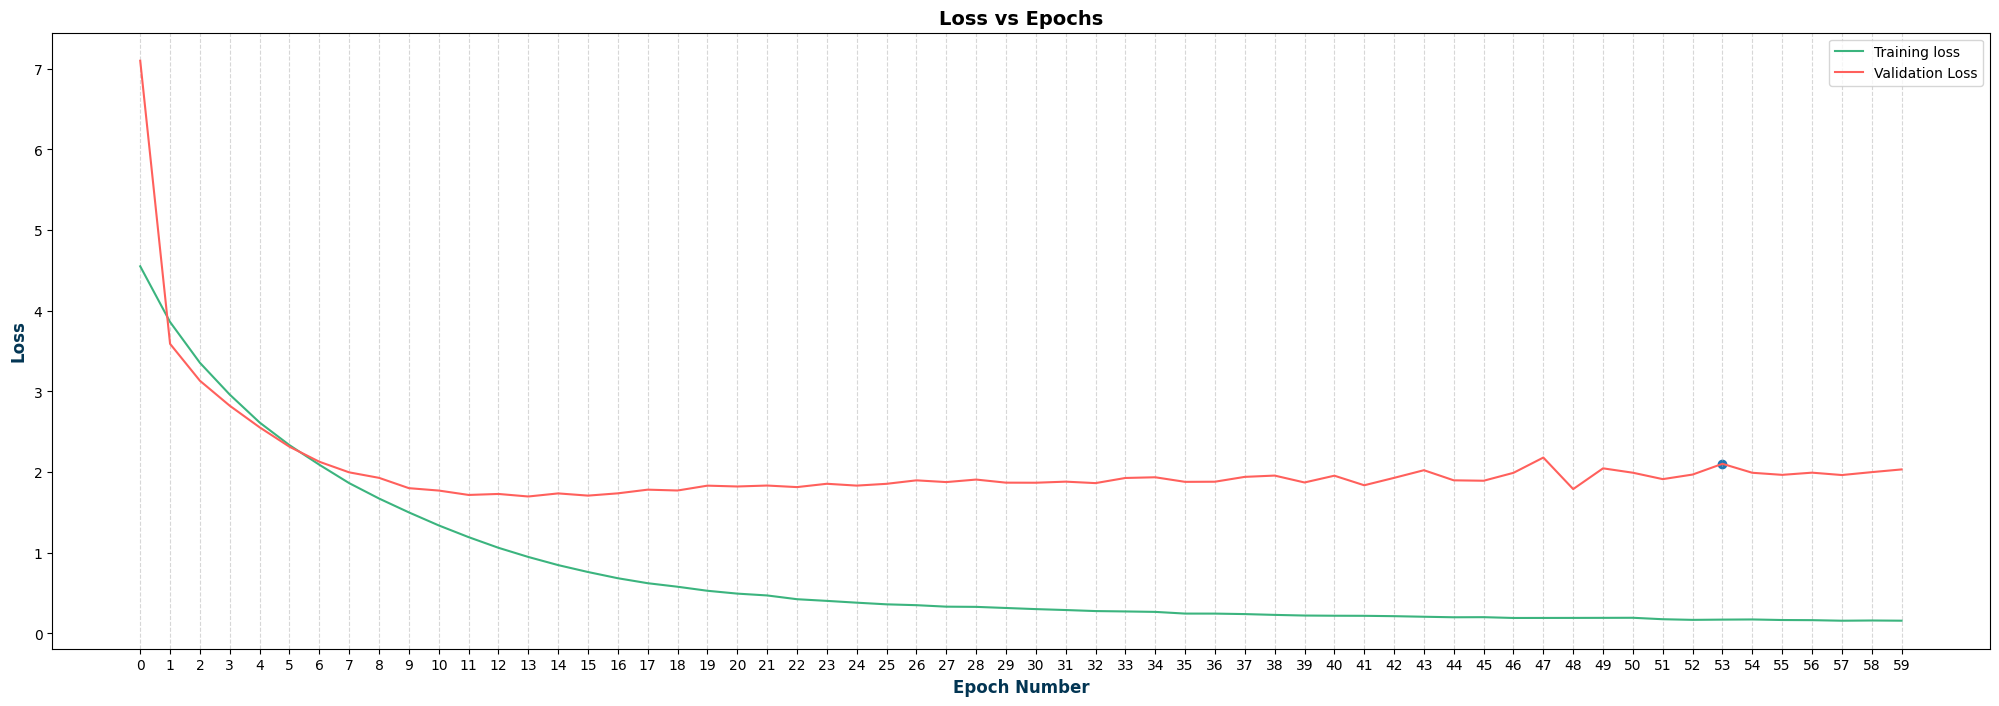

In [ ]:
title_font = {"family" : "arial", "color" : "k", "weight" : "bold", "size" : 14}
axes_font = {"family" : "arial", "color" : "#023553", "weight" : "bold", "size" : 12}

fig = plt.figure(figsize=(25, 8))

plt.plot(history["loss"], color="#3BB47E", label="Training loss")
plt.plot(history["val_loss"], color="#FF605C", label="Validation Loss")

plt.xticks(range(len(history["loss"])))

plt.legend(loc="upper right")

plt.title("Loss vs Epochs", fontdict = title_font)
plt.xlabel("Epoch Number", fontdict = axes_font)
plt.ylabel("Loss", fontdict = axes_font)

plt.grid(True, axis="x", alpha=0.5, linestyle="--")

max_val_acc_row_index = history_df[history_df["val_accuracy"] == max(history_df["val_accuracy"])].index[-1]

plt.scatter(max_val_acc_row_index,
            history_df.loc[max_val_acc_row_index, "val_loss"])

plt.show()

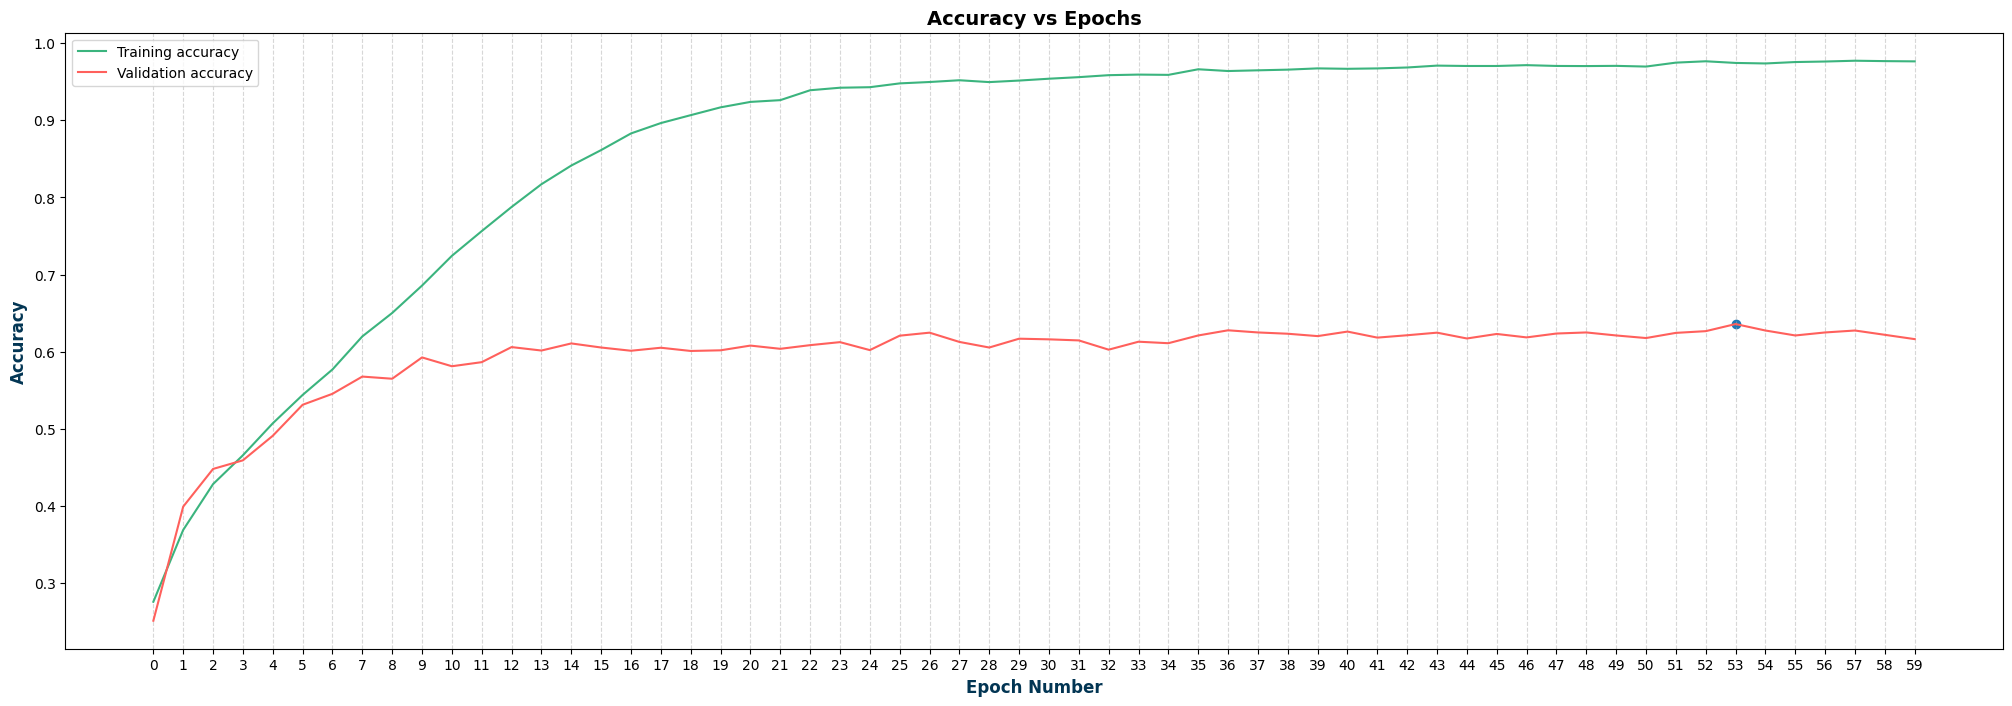

In [ ]:
title_font = {"family" : "arial", "color" : "k", "weight" : "bold", "size" : 14}
axes_font = {"family" : "arial", "color" : "#023553", "weight" : "bold", "size" : 12}

fig = plt.figure(figsize=(25, 8))

plt.plot(history["accuracy"], color="#3BB47E", label="Training accuracy")
plt.plot(history["val_accuracy"], color="#FF605C", label="Validation accuracy")

plt.xticks(range(len(history["accuracy"])))

plt.legend(loc="upper left")

plt.title("Accuracy vs Epochs", fontdict = title_font)
plt.xlabel("Epoch Number", fontdict = axes_font)
plt.ylabel("Accuracy", fontdict = axes_font)

plt.grid(True, axis="x", alpha=0.5, linestyle="--")

plt.scatter(max_val_acc_row_index,
            history_df.loc[max_val_acc_row_index, "val_accuracy"])

plt.show()

In [ ]:
accuracy = Accuracy()
categorical_accuracy = CategoricalAccuracy()

In [ ]:
test_directory = os.path.join("/content/drive/MyDrive/Project/Dataset/project", "test")

test = tf.keras.preprocessing.image_dataset_from_directory(test_directory,
                                                           image_size=(48, 48),
                                                           batch_size=64,
                                                           color_mode="grayscale")

Found 7178 files belonging to 7 classes.


In [ ]:
num_classes = 7
confusion_matrix = np.zeros((num_classes, num_classes))

for batch in test.as_numpy_iterator():

    test_data, test_target = batch
    test_target = to_categorical(test_target, num_classes=num_classes)

    test_target_pred = model.predict(test_data, verbose=0)

    categorical_accuracy.update_state(test_target, test_target_pred)
    accuracy.update_state(test_target, test_target_pred)

    test_target_pred_labels = np.argmax(test_target_pred, axis=1)

    batch_confusion_matrix = sk_confusion_matrix(np.argmax(test_target, axis=1), test_target_pred_labels, labels=range(num_classes))
    confusion_matrix += batch_confusion_matrix

In [ ]:
print("Testing Results")
print("-"*30)

print(f"Accuracy               {(accuracy.result()*100):.4f}")
print(f"Categorical Accuracy   {(categorical_accuracy.result()*100):.4f}")

Testing Results
------------------------------
Accuracy               79.1366
Categorical Accuracy   34.2157


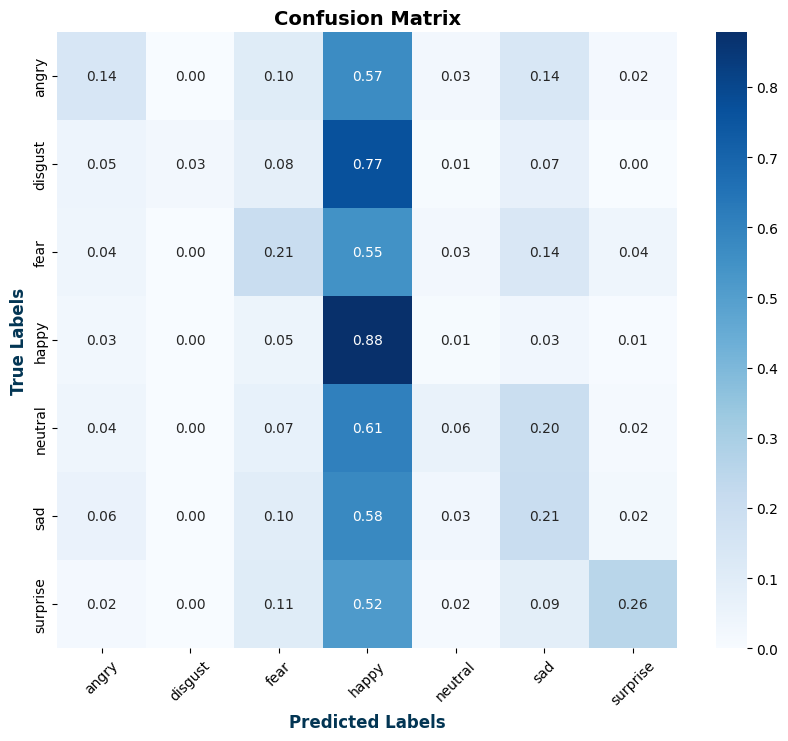

In [ ]:
title_font = {"family" : "arial", "color" : "k", "weight" : "bold", "size" : 14}
axes_font = {"family" : "arial", "color" : "#023553", "weight" : "bold", "size" : 12}

normalized_confusion_matrix = confusion_matrix / confusion_matrix.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))

heatmap = sns.heatmap(normalized_confusion_matrix, annot=True, fmt=".2f", cmap="Blues")

ax.set_xlabel("Predicted Labels", fontdict=axes_font)
ax.set_ylabel("True Labels", fontdict=axes_font)
ax.set_title("Confusion Matrix", fontdict=title_font)

ax.xaxis.set_ticklabels(expressions_list)
ax.yaxis.set_ticklabels(expressions_list)

plt.xticks(rotation=45)

plt.show()